# ARCS Control Analysis

## Setup

In [47]:
import numpy as np

import matplotlib.pyplot as plt

import emtk.EventModeAnalyser.EMAnalyser as ema

import importlib
importlib.reload(ema) 

import copy

RANDOM_SEED = 0
np.random.seed(seed=RANDOM_SEED)

import lmfit 

from scipy.stats import cauchy
from scipy.stats import norm
from scipy.stats import uniform

import copy

In [48]:
lineSize = 200000

truth = np.array([
    0.0, 20.0, 
    100.0, 25.0
    ])

elasticData = np.random.normal(loc=truth[0], scale=truth[1], size=lineSize)
line1Data = np.random.normal(loc=truth[2], scale=truth[3], size=int(lineSize/2)) 




""" We might need an integral function between two points (xmin, xmax) 
for every term in the fitting function, so that the relative likelihoods are 
normalised within the data bounds.  It will be good to check whether these
are actually needed or not in the final analysis, but in previous work
these proved to be necessary.
"""

def cauchy_integral(x1, x2, kappa):
    # Returns the integral of a cauchy distribution between two x values

    if x1 < x2:
        xmin = x1
        xmax = x2
    else:
        xmin = x2
        xmax = x1

    
    t1 = np.arctan(xmax/kappa)
    t2 = np.arctan(xmin/kappa)
    
    return (t1 - t2)/np.pi

    

def uniform_integral(x1, x2):
    # Returns the integral of a uniform distribution between two x values

    if(x1 == x2):
        return 0.0

    return np.absolute(x1-x2)



def gaussian_integral(x1, x2, mu=0.0, sigma=1.0):
    # Integral of a gaussian curve between two points
    t1 = norm.cdf(x1, loc=mu, scale=sigma)
    t2 = norm.cdf(x2, loc=mu, scale=sigma)
    intg = t1 - t2

    return np.absolute(intg)



## 2 Components

EMAnalyser object created with 300000 weighted events in range -97.04235306360233 - 202.52761508151374
Calculating KDE
Using silverman method
   - linear scale
nx 200
slice size 1.4903978514682392


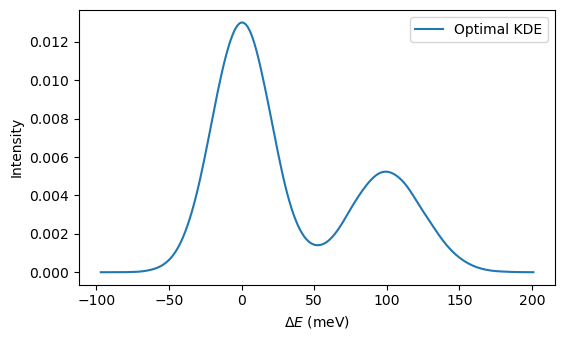

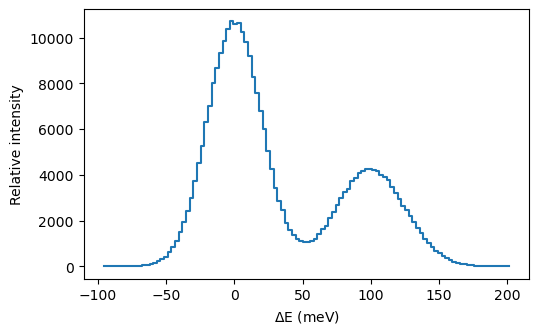

In [49]:
spectrum = np.concatenate([elasticData, line1Data])
weights = np.ones_like(spectrum)

ema1 = ema.EMAnalyser(spectrum, weights)

ema1.shuffle()

ema1.plot_kde(log=False, loglog=False, xlabel='$\Delta E$ (meV)', method="silverman")

# Manually replot and save histo figure for a paper
bn=ema1.optimal_n_bins()
hst = np.histogram(ema1.data, bins=bn, weights=ema1.weights)
hx=hst[1]
hy=hst[0]
# wipe over zero value artefacts
zind = np.where(hy==0.0)
for i in range(0, hx.size):
    if i > 0 and np.isin(i, zind):
        hy[i] = hy[i-1]
hx = hx[:-1]

#Thomas's shift
hx = hx + 0.5 * (hx[1] - hx[0])

fig,ax=plt.subplots()
ax.step(hx, hy, where='mid')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
#plt.xlim(-300,700)
plt.show()

In [50]:
def big_lse_pdf(x, amplitude, elmu, mu1, elsigma, s1, m1):
    
    mvals = ema1.simplex_weights(np.array([m1]))

    el = mvals[0] * norm.pdf(x, scale=elsigma, loc=elmu) / gaussian_integral(ema1.xmin, ema1.xmax, elsigma)

    l1 = mvals[1] * norm.pdf(x, scale=s1, loc=mu1) / gaussian_integral(ema1.xmin, ema1.xmax, mu1, s1)
    
    sol = amplitude * (el + l1)
    
    return sol

ema1.set_lse_function(big_lse_pdf)

ema1.make_lse_params(
    amplitude=dict(value=1.0, min=0.0),\
    elmu = dict(value=10.0, min=-100.0, max=100.0),\
    mu1 = dict(value=150.0, min=100.0, max=200.0),

    elsigma = dict(value=20.0, min=10.0, max=100.0),\
    s1 = dict(value=30.0, min=10.0, max=100.0),\
    s2 = dict(value=30.0, min=10.0, max=100.0),
    m1=dict(value=0.3, min=0.0, max = 1.0),\
    m2=dict(value=0.2, min=0.0, max = 1.0)
)

lse_starting_parameters = copy.deepcopy(ema1.least_squares_parameters)

Least squares model function defined.


['amplitude', 'elmu', 'mu1', 'elsigma', 's1', 'm1']
[  0.  20. 100.  25.]
[  1.00079343  -1.21307335 100.          20.00757126  25.02945571
   0.66725706]
[0.00244318 0.05970216 0.12530063 0.06074751 0.17099654 0.00147996]


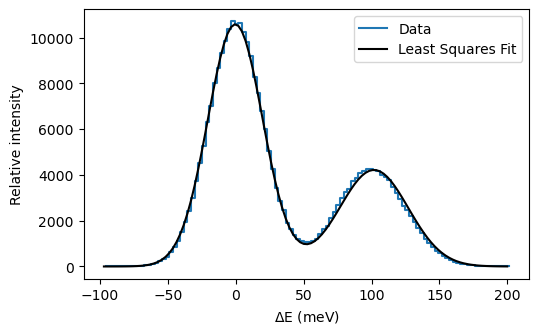

In [51]:
ema1.lse_fit()
#ema1.plot_LSE_fit(loglog=False, log=False, xlabel='meV', save="/Users/phillipbentley/Code/python/mle/arcs_lse_fit.png")

pnams = ema1.get_lse_param_names()
print(pnams)

print(truth)

pvals = ema1.get_lse_param_values()
print(pvals)

detailed_fit_params = pvals

psigs = ema1.get_lse_param_errors()
print(psigs)


detailed_fit_sigmas = psigs

# Manually replot and save figure for a paper
bn=ema1.optimal_n_bins()
hst = np.histogram(ema1.data, bins=bn, weights=ema1.weights)
hx=hst[1]
hy=hst[0]

# wipe over zero value artefacts
#zind = np.where(hy==0.0)
#for i in range(0, hx.size):
 #   if i > 0 and np.isin(i, zind):
  #      hy[i] = hy[i-1]
hx = hx[:-1]

#Thomas's shift
shifted_histo_x = hx + 0.5 * (hx[1] - hx[0])

fig,ax=plt.subplots()
fullhisto_x = hx
fullhisto_y = hy

ax.step(shifted_histo_x, fullhisto_y, where='mid', label='Data')
nhy = hy.size
shy = np.sum(hy)
nly = ema1.lse_result.best_fit.size
sly = np.sum(ema1.lse_result.best_fit)

scl = shy * nly / (nhy * sly)

full_data_fit_line = scl*ema1.lse_result.best_fit


#ax.plot(ema1.histx, full_data_fit_line, color='black', label='Least Squares Fit')
ax.plot(fullhisto_x, full_data_fit_line, color='black', label='Least Squares Fit')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.legend()
plt.show()

Subsampling in order.
Calculating KDE
Using silverman method
   - linear scale
nx 200
slice size 1.216193097999117


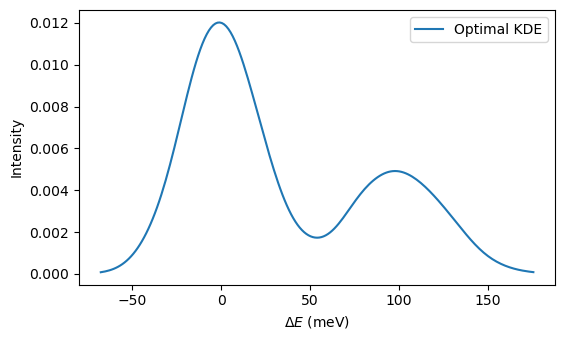

Least squares model function defined.
[  1.00820856  -5.04559762 100.          20.29649569  26.38597006
   0.6635719 ]


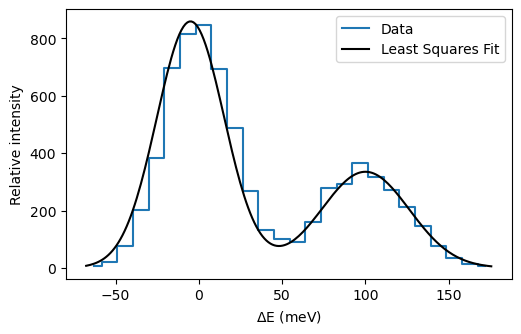

In [52]:
cpo = ema1.subsample(7000, randomize=False)


cpo.plot_kde(log=False, loglog=False, xlabel='$\Delta E$ (meV)', method="silverman")

cpo.set_lse_function(big_lse_pdf)


cpo.make_lse_params(
    
    amplitude=dict(value=1.0, min=0.0),\
    elmu = dict(value=10.0, min=-100.0, max=100.0),\
    mu1 = dict(value=150.0, min=100.0, max=200.0),

    elsigma = dict(value=20.0, min=10.0, max=100.0),\
    s1 = dict(value=30.0, min=10.0, max=100.0),\
    s2 = dict(value=30.0, min=10.0, max=100.0),
    m1=dict(value=0.3, min=0.0, max = 1.0),\
    m2=dict(value=0.2, min=0.0, max = 1.0)
)



cpo.lse_fit()
#ema1.plot_LSE_fit(loglog=False, log=False, xlabel='meV', save="/Users/phillipbentley/Code/python/mle/arcs_lse_fit.png")


sub_pvals = cpo.get_lse_param_values()
print(sub_pvals)

# Manually replot and save figure for a paper
bn=cpo.optimal_n_bins()
hst = np.histogram(cpo.data, bins=bn, weights=cpo.weights)
hx=hst[1]
hy=hst[0]

# wipe over zero value artefacts
zind = np.where(hy==0.0)
for i in range(0, hx.size):
    if i > 0 and np.isin(i, zind):
        hy[i] = hy[i-1]
hx = hx[:-1]
#Thomas's shift
hx = hx + 0.5 * (hx[1] - hx[0])

fig,ax=plt.subplots()

subsample_histo_x = hx
subsample_histo_y = hy



#sub_data_fit_line = scl*cpo.lse_result.best_fit
sub_data_fit_line = big_lse_pdf(cpo.kdex,
                            sub_pvals[0],
                            sub_pvals[1],
                            sub_pvals[2],
                            sub_pvals[3],
                            sub_pvals[4],
                            sub_pvals[5])

ax.step(subsample_histo_x, subsample_histo_y, where='mid', label='Data')
nhy = hy.size
shy = np.sum(hy)
nly = sub_data_fit_line.size
sly = np.sum(sub_data_fit_line)

scl = shy * nly / (nhy * sly)

sub_data_fit_line = sub_data_fit_line * scl

#ax.plot(ema1.histx, full_data_fit_line, color='black', label='Least Squares Fit')
ax.plot(cpo.kdex, sub_data_fit_line, color='black', label='Least Squares Fit')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.legend()
plt.show()


In [55]:
# Build MCMC Models with API

def simplex_weights(Qraw: np.ndarray) -> np.ndarray:
    # Raw Q values can run between 0-1 to keep things simple
    # The sum is assumed to be 1, preventing out of gamut values
    # That condition is enforced already in the last 4 terms of 
    # the log_prior above.
    # Note that Qraw has one dimension fewer
    # than the number of parameters, like this:
    # https://en.m.wikipedia.org/wiki/Ternary_plot
    
    Qraw = np.asarray(Qraw)
    
    Qsum = np.sum(Qraw)    
    Qlast = 1.0 - Qsum
    
    Qvals = np.append(Qraw, Qlast)
    return Qvals

def log_prior_function(theta):
    # The main role of this function is to set 
    # parameter bounds of the bayesian search space
    elmu, mu1, elsigma, s1, m1 = theta

    if -100.0 < elmu < 100.0 and \
        100.0 < mu1  < 200.0 and \
        10.0 < elsigma < 100.0 and \
        10.0 < s1 < 100.0 and \
        0.1 < m1 < 1.0:
        return 0.0
    
    return -np.inf



def probability_mass_function(theta, xx, xmin, xmax, pweights, verbose=False):
    
    elmu, mu1, elsigma, s1, m1 = theta

    pweights = np.asarray(pweights)
    
    if (pweights==None).any():
        use_weights = np.ones_like(xx)
    else:
        use_weights = pweights

    spscale = xmax-xmin


    mvals = simplex_weights(np.array([m1]))

    el = mvals[0] * norm.pdf(xx, scale=elsigma, loc=elmu) / gaussian_integral(ema1.xmin, ema1.xmax, elsigma)
    l1 = mvals[1] * norm.pdf(xx, scale=s1, loc=mu1) / gaussian_integral(ema1.xmin, ema1.xmax, mu1, s1)
    
    sol = (el + l1)**use_weights
    
    return sol



def log_likelihood_function(theta, data, xmin, xmax, pweights, mylpf, verbose=False):

    raiseError = False
    result = 0.0

    elmu, mu1, elsigma, s1, m1 = theta

    pweights = np.asarray(pweights)
    
    if (pweights==None).any():
        use_weights = np.ones_like(data)
    else:
        use_weights = pweights
        
    
    lp = mylpf(theta)
    
    if np.isinf(lp):
        return -np.inf

    mvals = simplex_weights(np.array([m1]))
    


    el = mvals[0] * norm.pdf(data, scale=elsigma, loc=elmu) / gaussian_integral(ema1.xmin, ema1.xmax, elsigma)
    l1 = mvals[1] * norm.pdf(data, scale=s1, loc=mu1) / gaussian_integral(ema1.xmin, ema1.xmax, mu1, s1)


    # Guard against zero values in each term
    minval = 1.0E-300

    msk = el < minval
    el[msk] = minval

    msk = l1 < minval
    l1[msk] = minval


    
 #   try:
    lel = np.log(el)
    ll1 = np.log(l1)

    lt1 = np.logaddexp(lel, ll1)

    lll = np.sum(lt1 * use_weights)
    
    result = lp + lll

    if np.isnan(result):
        print("NaN in log_likelihood at", theta)
        verbose=True
                    
    if verbose==True:
        print("lp", lp)
        print("lll", lll)
        print("l1", l1)
        print("")
        print("m0", mvals[0])
        print("m1", mvals[1])

    return result

    
#   except RuntimeWarning as e:
#        print("Runtime warning at", theta)
#        print(e)
#        raise
    


cpo.lpf = log_prior_function
cpo.pmf = probability_mass_function
cpo.llf = log_likelihood_function

# Seed MCMC search manually
# amplitude=dict(value=1.0, min=0.0),\
#    elmu = dict(value=10.0, min=-100.0, max=100.0),\
#    mu1 = dict(value=150.0, min=100.0, max=200.0),

#    elsigma = dict(value=20.0, min=10.0, max=100.0),\
#    s1 = dict(value=30.0, min=10.0, max=100.0),\
#    m1 = dict(value=0.5, min=0.0, max = 1.0)

same_as_least_squares = np.array([10.0, 150.0, 20, 30, 0.5])

#cpo.theta_seed = np.array([7.83319976e+00, 1.45695047e+02, 2.81254328e+02,\
# 4.14035526e+02, 5.52327378e+02, 6.99999691e+02, 2.30190791e-02,\
# 1.86422670e+01, 1.99165093e+01, 2.21066916e+01, 2.75136714e+01,\
# 2.79613790e+01, 1.16801601e+02, 4.02817313e+01, 1.90420268e-01,\
# 1.40207127e-01, 1.18191129e-01, 1.18351136e-01, 7.89817013e-02,\
# 2.74781599e-01])


cpo.theta_seed = same_as_least_squares

# Seed MCMC search with LSE fit
#cpo.lse_fit()
#cpo.theta_seed = detailed_fit_params # <- this takes parameters from the detailed fit done earlier
#cpo.theta_seed = cpo.theta_seed[1:]

#log_likelihood_function(theta, data, xmin, xmax, pweights, mylpf, verbose=False)
#test=log_likelihood_function(nan_location, ema1.data, np.amin(ema1.data), np.amax(ema1.data), ema1.weights, log_prior_function, verbose=True)

cpo.nwalkers=32 # need to increase this to improve sampling stats quality 
# (see plots of MCMC_parameter_distribution later) 

cpo.MCMC_fit(nburn=400, niter=200) # fixed number of iterations
#cpo.MCMC_fit(niter=5000, convergence="Gelman-Rubin") # gelman-rubin method to check for convergence


MCMC launch
Burn in:


100%|█████████████████████████████████████████| 400/400 [00:07<00:00, 54.63it/s]


Sampling:


100%|█████████████████████████████████████████| 200/200 [00:03<00:00, 55.07it/s]

MCMC sampling complete.


(200, 32, 5)
(200, 32, 5)


True

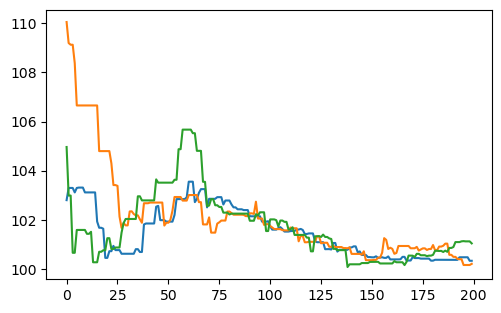

In [56]:
chz = cpo.sampler.get_chain()
nwk = cpo.nwalkers
ndm = cpo.ndim

rlen = chz.shape[0]

print(chz.shape)

burned = chz[-1000::]
#=np.delete(chz, np.s_[rlen-42:rlen], axis=0)
print(burned.shape)
ch1 = burned[:,1,1]
ch2 = burned[:,2,1]
ch3 = burned[:,3,1]
fig,ax=plt.subplots()
ax.plot(ch1)
ax.plot(ch2)
ax.plot(ch3)

cpo.self_check()

Calculating KDE
Using pmb method
   - linear scale
nx 200
slice size 1.216193097999117


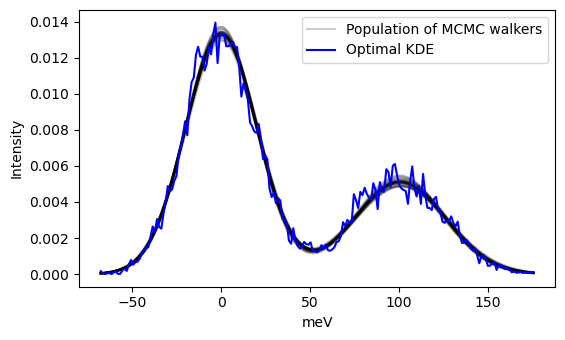

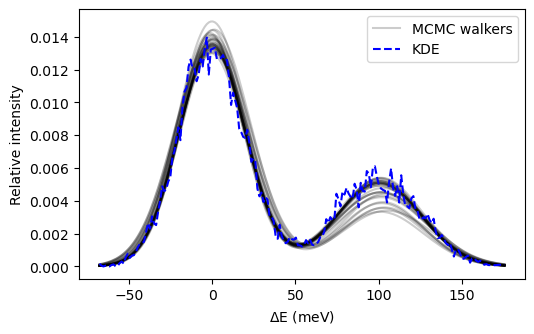

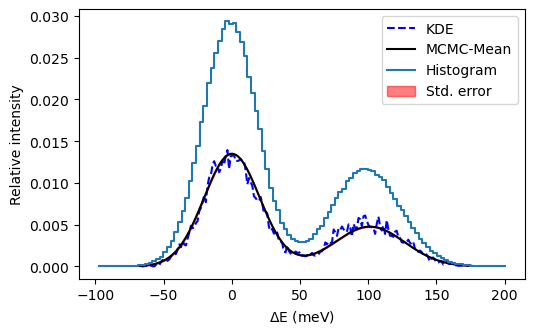

In [57]:
#cpo.plot_LSE_fit(loglog=False, log=False, xlabel='meV')
#cpo.plot_MCMC_fit(method="histo", loglog=False, log=False, xlabel='meV', save="arcs_mcmc_fit.png")

cpo.self_check()

cpo.plot_MCMC_fit(method='kde', loglog=False, log=False, xlabel='meV')
#cpo.plot_MCMC_fit(method='histo', loglog=False, log=False, xlabel='meV')

# Repeat plot manually for paper output

flt = cpo.sampler.get_chain(discard=20, thin=15, flat=True)
inds  = np.random.choice(len(flt), size=30, replace=False)
pt_sum = np.sum(cpo.kdey)

fig,ax=plt.subplots()

for ind in inds:
    smp = flt[ind]
    yfit = cpo.pmf(smp, cpo.kdex, cpo.xmin, cpo.xmax, None)
    ysum = np.sum(yfit)
    scale = pt_sum / ysum 
    yfit = yfit * scale

    if ind == inds[0]:
        ax.plot(cpo.kdex, yfit, color='black', alpha=0.2, label='MCMC walkers')
    else:
        ax.plot(cpo.kdex, yfit, color='black', alpha=0.2)

plt.plot(cpo.kdex, cpo.kdey, ls='--', color='blue', label='KDE')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
#plt.xlim([410, 435])
#plt.ylim([0.0014, 0.00195])
plt.legend()
plt.show()

# Plot showing the average of the PDFs over all walkers?
inds = np.arange(len(flt))


yfit = np.zeros((len(flt),cpo.kdex.size))

for ind in range(len(flt)):
    smp = flt[ind]
    yfit[ind] = cpo.pmf(smp, cpo.kdex, cpo.xmin, cpo.xmax, None)

ysum = np.sum(yfit, axis=0)

ymean = ysum / len(flt) #np.mean(yfit, axis=0)
ystd = np.std(yfit, axis=0)
ystd = ystd / np.sqrt(len(inds))

                
ysum = np.sum(ymean)
scale = pt_sum / ysum
ymean = ymean * scale
ystd = ystd * scale

stepsum = np.sum(fullhisto_y)
stepscale = pt_sum / stepsum

plt.plot(cpo.kdex, cpo.kdey, ls='--', color='blue', label='KDE')
plt.plot(cpo.kdex, ymean, color='black', label='MCMC-Mean')
plt.step(fullhisto_x, fullhisto_y*stepscale, where='mid', label='Histogram')
plt.fill_between(cpo.kdex, ymean-ystd, ymean+ystd, color='red', alpha=0.5, label='Std. error')
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
#plt.xlim([410, 435])
#plt.ylim([0.0014, 0.00195])
plt.legend()
fig.set_size_inches(6,4)
plt.show()

In [58]:
print("PEAK METHOD:")
mcpparams, mcperr = cpo.get_MCMC_parameters(method='peak')
print(mcpparams)
print(mcperr)

print()
print("MEAN METHOD:")
mcparams, mcerr = cpo.get_MCMC_parameters(method='mean')
print(mcparams)
print(mcerr)

print()
print("LSE on full data set")
lsparams = ema1.get_lse_param_values()


lserrors = ema1.get_lse_param_errors()
print(lsparams)
print(lserrors)

import pandas

pn = ema1.get_lse_param_names()
pn = pn[1:]

df = pandas.DataFrame({"PARAMETER": pn, "LSE": lsparams[1:], "LSE_ERR": lserrors[1:], "BAYES": mcparams, "BAYES_ERR": mcerr, "BAYES-PEAK": mcpparams, "BAYES-PEAK-ERR": mcperr})
print(df)

PEAK METHOD:
fwhm 6.489907629148135
fwhm 3.14684650455927
fwhm 5.596797671033478
fwhm 13.56559714795009
fwhm 2.2498275806762047
[-7.04945064e-02  1.00000600e+02  1.99045462e+01  2.54831181e+01
  6.68686941e-01]
[0.04775801 0.02315705 0.04118579 0.09982669 0.01655606]

MEAN METHOD:
stdd 0.9767822797929779
stdd 1.4284209805011834
stdd 1.278801658255256
stdd 1.1840256011410846
stdd 0.04812828436631194
[  0.28053899 101.46558863  20.82647887  25.69791427   0.70733596]
[0.01220978 0.01785526 0.01598502 0.01480032 0.0006016 ]

LSE on full data set
[  1.00079343  -1.21307335 100.          20.00757126  25.02945571
   0.66725706]
[0.00244318 0.05970216 0.12530063 0.06074751 0.17099654 0.00147996]
  PARAMETER         LSE   LSE_ERR       BAYES  BAYES_ERR  BAYES-PEAK  \
0      elmu   -1.213073  0.059702    0.280539   0.012210   -0.070495   
1       mu1  100.000000  0.125301  101.465589   0.017855  100.000600   
2   elsigma   20.007571  0.060748   20.826479   0.015985   19.904546   
3        s1   2

In [60]:
evs=spectrum

assumed_param_values = np.copy(mcparams)

RANDOM_SEED = 1
np.random.seed(seed=RANDOM_SEED)

maxsiz = np.log10(evs.size)
print(evs.size)
print(maxsiz)
evreps=10
n_evs = np.logspace(2, maxsiz, evreps).astype(int)
print(n_evs)
n_evs[-1]=evs.size
print(n_evs)

lse_results = np.zeros((evreps, mcparams.size+1))
lse_errors  = np.zeros((evreps, mcparams.size+1))
mcmc_results = np.zeros((evreps, mcparams.size))
mcmc_errors = np.zeros((evreps, mcparams.size))


lsMinEvents = 10000
mcmcMinEvents = 10
lsMaxEvents = 10000000
mcmcMaxEvents = 90000


rep = 0

for nn in n_evs:
    print("Rep", rep+1, "/", evreps, "|", nn, "/", evs.size)
    print("Subsampling...")
    sse = ema1.subsample(nn, randomize=False)
    # Manually subsample the first nn points instead of randomly subsampling them

    sse.lpf = log_prior_function
    sse.pmf = probability_mass_function
    sse.llf = log_likelihood_function


    if nn >= lsMinEvents and nn <= lsMaxEvents:
        print("Least Squares Analysis...")
        sse.least_squares_parameters = copy.deepcopy(lse_starting_parameters)
        sse.calculate_histogram()
        sse.lse_fit()
        #sse.plot_LSE_fit(loglog=False, log=False, xlabel='meV')


        lse_results[rep,:] = sse.get_lse_param_values()
        lse_errors[rep,:] = sse.get_lse_param_errors()
    else:
        print("Skipping Least Squares Analysis (too few events for stable fit)")

    if nn >= mcmcMinEvents and nn <= mcmcMaxEvents:
        print("MCMC Analysis...")
        sse.nwalkers=128 # need to increase this to improve sampling stats quality 
        # (on plots of MCMC_parameter_distribution) 

        sse.theta_seed = same_as_least_squares
        sse.MCMC_fit(nburn=400, niter=150)

        mcmc_results[rep,:], mcmc_errors[rep,:] = sse.get_MCMC_parameters(method='mean')
    else:
        print("Skipping MCMC Analysis (too many events to run on a laptop in sensible time)")

    rep = rep + 1

print("Convergence loop complete.")

300000
5.477121254719663
[   100    243    592   1442   3510   8545  20800  50632 123246 300000]
[   100    243    592   1442   3510   8545  20800  50632 123246 300000]
Rep 1 / 10 | 100 / 300000
Subsampling...
Subsampling in order.
Skipping Least Squares Analysis (too few events for stable fit)
MCMC Analysis...
MCMC launch
Burn in:


100%|█████████████████████████████████████████| 400/400 [00:08<00:00, 45.38it/s]


Sampling:


100%|█████████████████████████████████████████| 150/150 [00:03<00:00, 45.53it/s]


MCMC sampling complete.
stdd 7.097433882303868
stdd 19.21588035828977
stdd 5.970193784165576
stdd 6.703997110962193
stdd 0.08252421615463021
Rep 2 / 10 | 243 / 300000
Subsampling...
Subsampling in order.
Skipping Least Squares Analysis (too few events for stable fit)
MCMC Analysis...
MCMC launch
Burn in:


...

MCMC sampling complete.
stdd 0.17919879217883344
stdd 0.13041412113681336
stdd 0.13678803043995857
stdd 0.25424484812895204
stdd 0.003371792871299025
Rep 8 / 10 | 50632 / 300000
Subsampling...
Subsampling in order.
Least Squares Analysis...
MCMC Analysis...
MCMC launch
Burn in:


100%|█████████████████████████████████████████| 400/400 [02:39<00:00,  2.52it/s]


Sampling:


100%|█████████████████████████████████████████| 150/150 [00:56<00:00,  2.66it/s]

MCMC sampling complete.
stdd 0.11156823229265712
stdd 0.10855008542259778
stdd 0.08757864135101963
stdd 0.16278401353993951
stdd 0.0021114143236239218
Rep 9 / 10 | 123246 / 300000
Subsampling...
Subsampling in order.
Least Squares Analysis...
Skipping MCMC Analysis (too many events to run on a laptop in sensible time)
Rep 10 / 10 | 300000 / 300000
Subsampling...
Subsample will return a direct copy of the data instead.
Least Squares Analysis...
Skipping MCMC Analysis (too many events to run on a laptop in sensible time)
Convergence loop complete.


In [72]:
def p_conv_plot(item, param_name='', Bayes=True, LSE=True, savename='', correct=np.inf, ylims=[np.inf, np.inf]):

    # Least squares parameters
    pnams = sse.get_lse_param_names()
    pnam = pnams[item+1]
    
    lsnevs = n_evs
    lsvalues = lse_results[:,item+1]
    lserrs = lse_errors[:,item+1]

    lsmask = lsvalues != 0.0
    lsnevs = lsnevs[lsmask]
    lsvalues = lsvalues[lsmask]
    lserrs = lserrs[lsmask]
    
    lsbtop = lsvalues+lserrs
    lsbbot = lsvalues-lserrs
    lswtop = np.amax(lsvalues)
    lswbot = np.amin(lsvalues)

    # Bayesian parameters
    mcnevs = n_evs
    mcvalues = mcmc_results[:,item]
    mcerrs = mcmc_errors[:,item]

    mcmask = mcvalues != 0.0
    mcvalues = mcvalues[mcmask]
    mcerrs = mcerrs[mcmask]
    mcnevs = mcnevs[mcmask]
    
    
    mcbtop = mcvalues+mcerrs
    mcbbot = mcvalues-mcerrs
    mcwtop = np.amax(mcvalues)
    mcwbot = np.amin(mcvalues)
    
    
    wtop = np.amax([lswtop, mcwtop])
    wbot = np.amin([lswbot, mcwbot])

    wspan = wtop - wbot
    wpad = wspan * 0.1
    wtop = wtop + np.abs(wpad)
    wbot = wbot - np.abs(wpad)

        
    fig, ax = plt.subplots()
    if LSE:
        ax.plot(lsnevs, lsvalues, color='blue', label='LSE')
        ax.fill_between(lsnevs, lsbbot, lsbtop, color='blue', alpha=0.15, label='LSE std. err')
        ax.set_ylim([wbot, wtop])
        ax.set_xlabel("# events")
        ax.set_ylabel(pnam + "Value")
        if param_name != '':
            ax.set_ylabel(param_name)

    if Bayes:
        ax.plot(mcnevs, mcvalues, color='red', label='Bayes')
        ax.fill_between(mcnevs, mcbbot, mcbtop, color='red', alpha=0.15, label='Bayes std. err')

    if np.isfinite(correct):
        xmin=np.amin(mcnevs)
        xmax=np.amax(lsnevs)
        plt.hlines(correct, xmin, xmax, label='Truth', ls='--', color='orange')


    if np.isfinite(ylims).all():
        plt.ylim(ylims)
    
    
    plt.xscale('log')
    plt.yscale('linear')
    ax.legend()

        

    if savename != '':
        plt.savefig(savename, dpi=600, bbox_inches='tight')
        plt.show()
    
    #print(sse.get_lse_param_names())

    

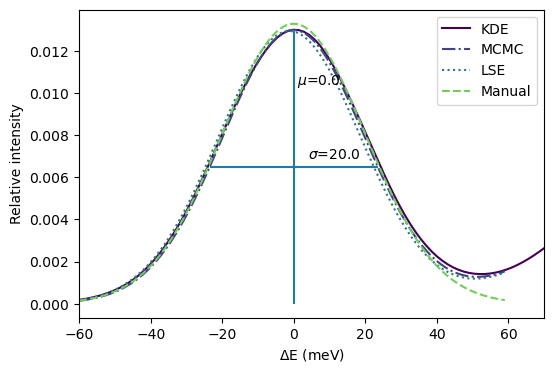

In [69]:
#ema1.plot_kde(loglog=False,log=False, xlabel='meV', method='silverman')

import scipy as sp


mu=truth[0]
sig=truth[1]
normval=1.5
ht=0.013

px=np.arange(-60,60,1)
nrm = sp.stats.norm(loc=mu,scale=sig)
py=nrm.pdf(px)/normval

ema1.pmf = probability_mass_function

lstrimp = np.delete(lsparams, 0)

mcmcy = ema1.pmf(mcpparams, px, ema1.xmin, ema1.xmax, None)
lsey = ema1.pmf(lstrimp, px, ema1.xmin, ema1.xmax, None)

mcmcy_sum = np.sum(mcmcy)
lsey_sum = np.sum(lsey)
py_sum = np.sum(py)

mcmcy = mcmcy * py_sum/mcmcy_sum
lsey = lsey * py_sum/lsey_sum

import matplotlib as mpl
colors = mpl.colormaps['viridis'].colors

fig,ax=plt.subplots()
plt.plot(ema1.kdex, ema1.kdey, label='KDE', color=colors[1])
plt.plot(px, mcmcy, ls='-.',label='MCMC', color=colors[50])
plt.plot(px, lsey, ls=':', label='LSE', color=colors[100])
plt.plot(px, py, ls='--', label='Manual', color=colors[200])
plt.xlabel('$\Delta$E (meV)')
plt.ylabel('Relative intensity')
plt.vlines(mu, 0.0, ht)
plt.hlines(ht/2.0, mu-2.355*sig/2.0, mu+2.355*sig/2.0)
ax.text(mu+1, ht*0.8, "$\mu$=" + str(mu))
ax.text(mu+4, ht*0.53, "$\sigma$=" + str(sig))
fig.set_size_inches(6,4)
plt.xlim([-60,70])
plt.legend()
plt.show()

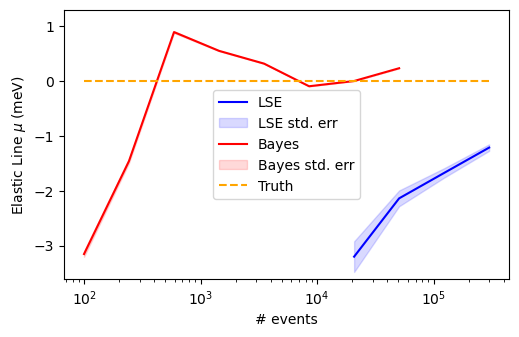

In [75]:
parameter_no = 0
p_conv_plot(parameter_no, param_name='Elastic Line $\mu$ (meV)', savename='', correct=truth[0])
#p_conv_plot(parameter_no, LSE=False)

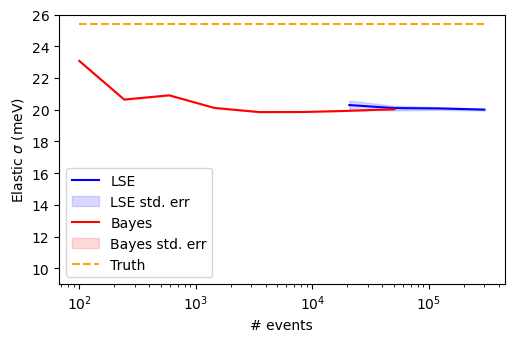

In [76]:
parameter_no = 2
p_conv_plot(parameter_no, param_name='Elastic $\sigma$ (meV)', savename='', correct=25.4, ylims=[9, 26])
#p_conv_plot(parameter_no, LSE=False)

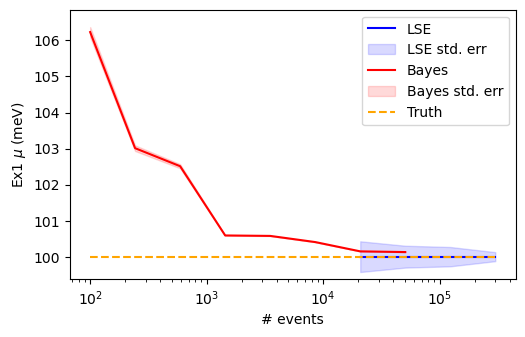

In [79]:
parameter_no = 1
p_conv_plot(parameter_no, param_name='Ex1 $\mu$ (meV)', savename='', correct=truth[2])
#p_conv_plot(parameter_no, LSE=False)

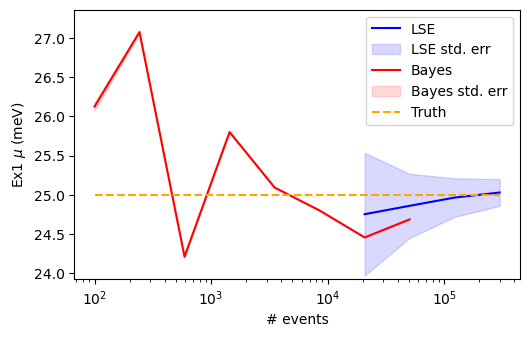

In [80]:
parameter_no = 3
p_conv_plot(parameter_no, param_name='Ex1 $\mu$ (meV)', savename='', correct=truth[3])